# Model generation & validation
We will try a few different classifier to create a model which can predict customer churning for the provided energy data, we will be try a few different modelling techniques here-

1. logistic regression
2. random forest
3. xgboost
4. lightGBM

In [2]:
import sys, os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
# importing nessaary util functions
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("../"), ".")))
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [3]:
# importing nessaary util functions
from utils.utils import split_data, apply_smote, train_model, tune_model_with_gridsearch, run_multiple_classifiers

In [4]:
# processed_df_path should go in the config.yaml
df_path = "../data/processed/churn_data_feat_eng.csv"
df = pd.read_csv(df_path)

In [5]:
df.head()

,UsageData,BillingAmount,CostPerUnit,IsShortContractedCust,HighUsageFlag,PaymentHistory,ContractType,Gender,BilltoIncomeRatio,is_churned,Age_25,Age_25-35,Age_35-50,Age_50-65,Age_65+,contract_Dr_0-6m,contract_Dr_6-12m,contract_Dr_12-18m,contract_Dr_18-24m,income_40k,income_40-60k,income_60-80k,income_80-100k,income_100k+,hh_bin_Small_(1-2),hh_bin_Medium_(3-5),hh_bin_Large_(6+),engage_Loyal,engage_At_Risk,engage_High_Risk,engage_Critical
0,1.476368,-0.001302,-0.365709,0,1,1,1,0,-0.023944,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0
1,-0.031844,1.466846,-0.053086,0,0,1,1,0,-0.024544,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0
2,-0.753599,0.876223,0.092337,0,0,1,0,1,-0.025290,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0
3,-0.351418,0.093013,-0.184084,0,0,1,1,0,-0.023259,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0
4,-1.016364,-0.934787,-0.236384,0,0,1,0,1,-0.023044,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1


In [6]:
df.columns

Index(['UsageData', 'BillingAmount', 'CostPerUnit', 'IsShortContractedCust',
       'HighUsageFlag', 'PaymentHistory', 'ContractType', 'Gender',
       'BilltoIncomeRatio', 'is_churned', 'Age_25', 'Age_25-35', 'Age_35-50',
       'Age_50-65', 'Age_65+', 'contract_Dr_0-6m', 'contract_Dr_6-12m',
       'contract_Dr_12-18m', 'contract_Dr_18-24m', 'income_40k',
       'income_40-60k', 'income_60-80k', 'income_80-100k', 'income_100k+',
       'hh_bin_Small_(1-2)', 'hh_bin_Medium_(3-5)', 'hh_bin_Large_(6+)',
       'engage_Loyal', 'engage_At_Risk', 'engage_High_Risk',
       'engage_Critical'],
      dtype='object')

In [8]:
# excluded features from PCA
excluded_from_scaling = ['IsShortContractedCust', 'HighUsageFlag', 'ContractType', 'Gender', 'PaymentHistory']

X_train, X_test, y_train, y_test, scaler, pca_model = split_data(
    df=df,
    target='is_churned',
    scale=False,
    test_size=0.2,
    pca=False,
    exclude_from_pca=excluded_from_scaling
)

In [9]:
X_test.head()

,UsageData,BillingAmount,CostPerUnit,BilltoIncomeRatio,Age_25,Age_25-35,Age_35-50,Age_50-65,Age_65+,contract_Dr_0-6m,contract_Dr_6-12m,contract_Dr_12-18m,contract_Dr_18-24m,income_40k,income_40-60k,income_60-80k,income_80-100k,income_100k+,hh_bin_Small_(1-2),hh_bin_Medium_(3-5),hh_bin_Large_(6+),engage_Loyal,engage_At_Risk,engage_High_Risk,engage_Critical,IsShortContractedCust,HighUsageFlag,ContractType,Gender,PaymentHistory
7979,-0.456430,0.677509,-0.060493,-0.023407,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,1
3220,-0.031844,-0.001302,-0.250976,-0.022126,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,1
4708,1.626638,0.011804,-0.370924,-0.024446,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,1,1,1,1
618,1.612667,-1.409269,-0.474116,-0.004095,0,0,1,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,1,1
6524,0.551660,1.683707,-0.136938,-0.023857,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,1,0,1,1,1


In [10]:
X_train.head()

,UsageData,BillingAmount,CostPerUnit,BilltoIncomeRatio,Age_25,Age_25-35,Age_35-50,Age_50-65,Age_65+,contract_Dr_0-6m,contract_Dr_6-12m,contract_Dr_12-18m,contract_Dr_18-24m,income_40k,income_40-60k,income_60-80k,income_80-100k,income_100k+,hh_bin_Small_(1-2),hh_bin_Medium_(3-5),hh_bin_Large_(6+),engage_Loyal,engage_At_Risk,engage_High_Risk,engage_Critical,IsShortContractedCust,HighUsageFlag,ContractType,Gender,PaymentHistory
9937,-0.528879,-0.758383,-0.297857,-0.017114,0,0,0,1,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,1,0,0,0,1
11053,-0.590835,0.045111,-0.136166,-0.020962,0,0,1,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,1
4523,1.384184,0.166588,-0.348562,-0.023975,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,1,1
7829,1.927980,0.221874,-0.367837,-0.022873,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,1,0,0,1
5417,-0.007907,-0.216078,-0.282768,-0.020208,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,1,0,0,0,1


In [11]:
# Calculate scale_pos_weight for XGBoost
scale_pos_weight = len(y_train) / sum(y_train)

model_list = [
    ('logistic', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ('random_forest', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
    ('svm', SVC(probability=True, class_weight='balanced', random_state=42)),
    ('xgboost', XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight, random_state=42)),
    ('lightgbm', LGBMClassifier(random_state=42)),
    ('decision_tree', DecisionTreeClassifier(random_state=42, class_weight='balanced')),
    ('grad_boost', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
]

In [12]:
results, fitted_model_1 = run_multiple_classifiers(X_train, X_test, y_train, y_test,
                              model_list=model_list,
                              lift_cutoffs=[0.1, 0.2])

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:54:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 926, number of negative: 8610
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000504 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1072
[LightGBM] [Info] Number of data points in the train set: 9536, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.097106 -> initscore=-2.229805
[LightGBM] [Info] Start training from score -2.229805


In [13]:
results

,model,precision,recall,f1_score,lift_at_top_10%,lift_at_top_20%
0,logistic,0.090,0.444,0.149,0.604,0.756
1,random_forest,0.333,0.004,0.009,0.691,0.756
2,svm,0.000,0.000,0.000,0.518,0.734
3,xgboost,0.098,0.138,0.114,0.993,1.123
4,lightgbm,0.000,0.000,0.000,0.864,0.950
5,decision_tree,0.100,0.099,0.099,1.036,0.993
6,grad_boost,0.000,0.000,0.000,0.907,0.885


/var/folders/7w/dgslt9rx39qb89n089jly0tm0000gn/T/ipykernel_77929/3808365057.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')


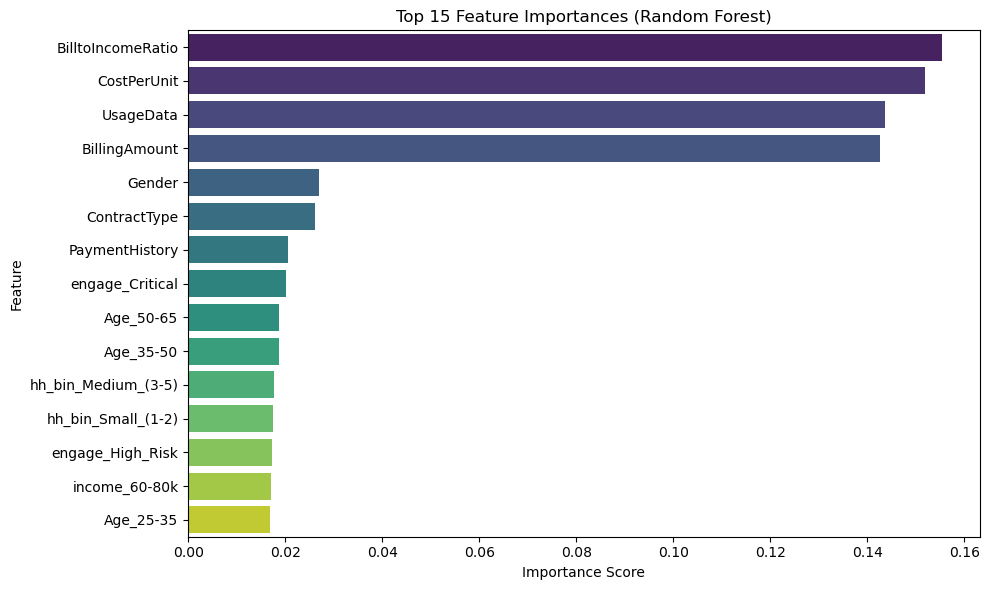

In [ ]:
X = X_train
y = y_train

#Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight= 'balanced')
rf.fit(X, y)

#Get feature importances
importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

#Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [15]:
y_train.value_counts()

is_churned
0    8610
1     926
Name: count, dtype: int64

There is massive class imbalance in the dataset, which is common amongst churn problems, I will fix it using two techniques-
1. RandomUnderSampler, which reduces the noise from the not_churned customers.
2. OverSampling using SMOTE, which increases the class size for the churned users.

In [16]:
# simple under-sampling
#from imblearn.under_sampling import RandomUnderSampler
#rus = RandomUnderSampler(sampling_strategy={0:3000, 1:934}, random_state=42)
#X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

In [17]:
#y_train_resampled.value_counts()


In [18]:
# Apply cube centriods to the training set only

X_train_bal, y_train_bal = apply_smote(X_train, y_train, 
                                               excluded_from_scaling=excluded_from_scaling, scale=False, tomek=True)
X_train_bal = pd.DataFrame(X_train_bal, columns=X_train.columns)

In [19]:
y_train_bal.value_counts()

is_churned
0    8530
1    4225
Name: count, dtype: int64

In [ ]:
#undersample using centroids, scaling is set false as it was already done in previous step
X_train_bal, y_train_bal = apply_smote(X_train_bal, y_train_bal, 
                                               excluded_from_scaling=excluded_from_scaling, scale=False, cube=True)
X_train_bal = pd.DataFrame(X_train_bal, columns=X_train.columns)

In [21]:
X_train_bal.head()

,UsageData,BillingAmount,CostPerUnit,BilltoIncomeRatio,Age_25,Age_25-35,Age_35-50,Age_50-65,Age_65+,contract_Dr_0-6m,contract_Dr_6-12m,contract_Dr_12-18m,contract_Dr_18-24m,income_40k,income_40-60k,income_60-80k,income_80-100k,income_100k+,hh_bin_Small_(1-2),hh_bin_Medium_(3-5),hh_bin_Large_(6+),engage_Loyal,engage_At_Risk,engage_High_Risk,engage_Critical,IsShortContractedCust,HighUsageFlag,ContractType,Gender,PaymentHistory
0,-1.444669,-1.414974,-0.249711,-0.004417,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,1,0,1
1,-0.944556,0.045111,-0.006637,-0.023010,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,1
2,0.095540,-0.003210,-0.267370,-0.021845,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,1,1
3,1.023740,-1.949131,-0.513528,105.133131,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,1,1,1,1,1
4,1.832742,1.059394,-0.306583,-0.023488,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0,1,0,1,1


In [22]:
y_train_bal.value_counts()

is_churned
0    8450
1    4225
Name: count, dtype: int64

In [23]:
X_train_bal.shape

(12675, 30)

In [24]:
X_test.shape

(2384, 30)

/var/folders/7w/dgslt9rx39qb89n089jly0tm0000gn/T/ipykernel_77929/830595382.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')


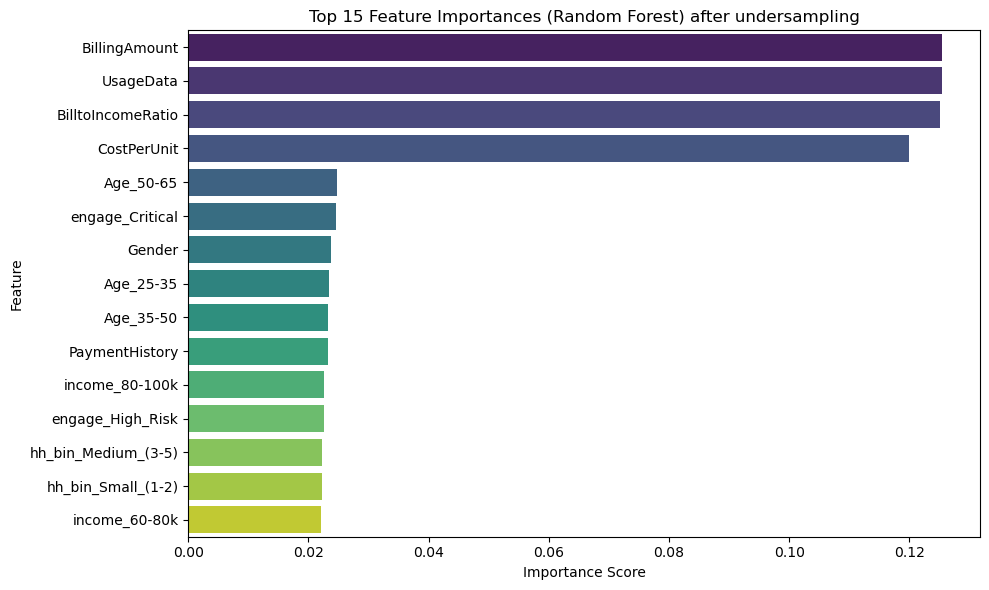

In [ ]:
X = X_train_bal
y = y_train_bal

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight= 'balanced')
rf.fit(X, y)

#Get feature importances
importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Step 4: Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title("Top 15 Feature Importances (Random Forest) after undersampling")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [26]:
X_train_bal.head()

,UsageData,BillingAmount,CostPerUnit,BilltoIncomeRatio,Age_25,Age_25-35,Age_35-50,Age_50-65,Age_65+,contract_Dr_0-6m,contract_Dr_6-12m,contract_Dr_12-18m,contract_Dr_18-24m,income_40k,income_40-60k,income_60-80k,income_80-100k,income_100k+,hh_bin_Small_(1-2),hh_bin_Medium_(3-5),hh_bin_Large_(6+),engage_Loyal,engage_At_Risk,engage_High_Risk,engage_Critical,IsShortContractedCust,HighUsageFlag,ContractType,Gender,PaymentHistory
0,-1.444669,-1.414974,-0.249711,-0.004417,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,1,0,1
1,-0.944556,0.045111,-0.006637,-0.023010,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,1
2,0.095540,-0.003210,-0.267370,-0.021845,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,1,1
3,1.023740,-1.949131,-0.513528,105.133131,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,1,1,1,1,1
4,1.832742,1.059394,-0.306583,-0.023488,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0,1,0,1,1


#### Use only PCA feature to train the models

In [29]:
# Calculate scale_pos_weight for XGBoost
scale_pos_weight = len(y_train) / sum(y_train)

model_list = [
    ('logistic', LogisticRegression(max_iter=1000,  random_state=42)),
    ('random_forest', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')),
    ('svm', SVC(probability=True, random_state=42)),
    ('xgboost', XGBClassifier(use_label_encoder=False, scale_pos_weight=scale_pos_weight, random_state=42)),
    ('lightgbm', LGBMClassifier(random_state=42)),
    ('decision_tree', DecisionTreeClassifier(random_state=42)),
    ('grad_boost', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
]

In [30]:
results_smote, fitted_model_3 = run_multiple_classifiers(X_train_bal, X_test, y_train_bal, y_test,
                              model_list=model_list,
                              lift_cutoffs=[0.1, 0.2])

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:55:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 4225, number of negative: 8450
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000448 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1072
[LightGBM] [Info] Number of data points in the train set: 12675, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147


In [31]:
results_smote

,model,precision,recall,f1_score,lift_at_top_10%,lift_at_top_20%
0,logistic,0.000,0.000,0.000,0.820,0.777
1,random_forest,0.053,0.009,0.015,0.907,0.820
2,svm,0.000,0.000,0.000,0.648,0.907
3,xgboost,0.101,0.190,0.132,0.907,0.993
4,lightgbm,0.092,0.099,0.095,0.907,0.907
5,decision_tree,0.115,0.185,0.142,1.209,1.123
6,grad_boost,0.000,0.000,0.000,0.907,0.885


In [32]:
# let's adjust the classification thresold-
results_smote_adj_thresold, fitted_models = run_multiple_classifiers(X_train_bal, X_test, y_train_bal, y_test,
                              model_list=model_list,
                              threshold=0.3,
                              lift_cutoffs=[0.1, 0.2])

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:56:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 4225, number of negative: 8450
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000471 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1072
[LightGBM] [Info] Number of data points in the train set: 12675, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147


In [33]:
results_smote_adj_thresold

,model,precision,recall,f1_score,lift_at_top_10%,lift_at_top_20%
0,logistic,0.111,0.009,0.016,0.820,0.777
1,random_forest,0.079,0.108,0.091,0.907,0.820
2,svm,0.042,0.009,0.014,0.648,0.907
3,xgboost,0.093,0.345,0.147,0.907,0.993
4,lightgbm,0.078,0.129,0.097,0.907,0.907
5,decision_tree,0.115,0.185,0.142,1.209,1.123
6,grad_boost,0.088,0.211,0.124,0.907,0.885


In [ ]:
from sklearn.ensemble import VotingClassifier

# Combine the trained models into a soft voting ensemble
ensemble_model = VotingClassifier(
    estimators=[('rf', fitted_models['random_forest']), ('xgb', fitted_models['xgboost']), ('gb', fitted_models['grad_boost'])],
    voting='soft'
)

# Train the ensemble on the training data
ensemble_model.fit(X_train_bal, y_train_bal)

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:56:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=No...
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('gb',
                              GradientBoostingClassifier(random_state=42))],
                 voting='soft')

In [35]:
X_test.head()

,UsageData,BillingAmount,CostPerUnit,BilltoIncomeRatio,Age_25,Age_25-35,Age_35-50,Age_50-65,Age_65+,contract_Dr_0-6m,contract_Dr_6-12m,contract_Dr_12-18m,contract_Dr_18-24m,income_40k,income_40-60k,income_60-80k,income_80-100k,income_100k+,hh_bin_Small_(1-2),hh_bin_Medium_(3-5),hh_bin_Large_(6+),engage_Loyal,engage_At_Risk,engage_High_Risk,engage_Critical,IsShortContractedCust,HighUsageFlag,ContractType,Gender,PaymentHistory
7979,-0.456430,0.677509,-0.060493,-0.023407,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,1
3220,-0.031844,-0.001302,-0.250976,-0.022126,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,1
4708,1.626638,0.011804,-0.370924,-0.024446,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,1,1,1,1
618,1.612667,-1.409269,-0.474116,-0.004095,0,0,1,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,1,1
6524,0.551660,1.683707,-0.136938,-0.023857,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,1,0,1,1,1


In [36]:
X_train_bal.head()

,UsageData,BillingAmount,CostPerUnit,BilltoIncomeRatio,Age_25,Age_25-35,Age_35-50,Age_50-65,Age_65+,contract_Dr_0-6m,contract_Dr_6-12m,contract_Dr_12-18m,contract_Dr_18-24m,income_40k,income_40-60k,income_60-80k,income_80-100k,income_100k+,hh_bin_Small_(1-2),hh_bin_Medium_(3-5),hh_bin_Large_(6+),engage_Loyal,engage_At_Risk,engage_High_Risk,engage_Critical,IsShortContractedCust,HighUsageFlag,ContractType,Gender,PaymentHistory
0,-1.444669,-1.414974,-0.249711,-0.004417,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,1,0,1
1,-0.944556,0.045111,-0.006637,-0.023010,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,1
2,0.095540,-0.003210,-0.267370,-0.021845,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,1,1
3,1.023740,-1.949131,-0.513528,105.133131,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,1,1,1,1,1
4,1.832742,1.059394,-0.306583,-0.023488,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0,1,0,1,1


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score


y_pred = ensemble_model.predict(X_test)

precision = precision_score(y_test, y_pred, pos_label=1)
recall    = recall_score(y_test, y_pred, pos_label=1)
f1        = f1_score(y_test, y_pred, pos_label=1)

# Calculate Lift at top 10%
y_proba = ensemble_model.predict_proba(X_test)[:, 1]  # probability of class 1 (churn)
y_pred = (y_proba >= 0.3).astype(int)
top_n = int(0.10 * len(y_proba))

# Find the indices of the top 10% customers by predicted churn probability
top_indices = np.argsort(-y_proba)[:top_n]

# Calculate how many of these top 10% actually churned
actual_churn_top_n = (y_test.iloc[top_indices] == 1).sum()

# Compute precision in top 10% group and baseline churn rate
precision_top10 = actual_churn_top_n / top_n
baseline_rate   = (y_test == 1).mean()

lift_top10 = precision_top10 / baseline_rate

# Print the evaluation metrics
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"Lift (top 10%): {lift_top10:.2f}")

Precision: 0.0820
Recall:    0.0216
F1-score:  0.0341
Lift (top 10%): 0.86


#### Stacked ensemble model using meta_learner as lightGBM

In [38]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
]

meta_model = LogisticRegression()

stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_model,
    cv=5,
    passthrough=False
)

stacking_clf.fit(X_train_bal, y_train_bal)
y_pred = stacking_clf.predict(X_test)

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:56:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:56:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:56:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:56:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

In [ ]:

y_pred = stacking_clf.predict(X_test)

precision = precision_score(y_test, y_pred, pos_label=1)
recall    = recall_score(y_test, y_pred, pos_label=1)
f1        = f1_score(y_test, y_pred, pos_label=1)

# Calculate Lift at top 10%
# Get churn probability predictions for each test sample
y_proba = ensemble_model.predict_proba(X_test)[:, 1]  # probability of class 1 (churn)
y_pred = (y_proba >= 0.3).astype(int)
# Determine the number of customers constituting 10% of the test set
top_n = int(0.10 * len(y_proba))
top_indices = np.argsort(-y_proba)[:top_n]  # argsort in descending order
# Calculate how many of these top 10% actually churned
actual_churn_top_n = (y_test.iloc[top_indices] == 1).sum()

precision_top10 = actual_churn_top_n / top_n
baseline_rate   = (y_test == 1).mean()


lift_top10 = precision_top10 / baseline_rate

# Print the evaluation metrics
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"Lift (top 10%): {lift_top10:.2f}")

Precision: 0.0735
Recall:    0.0216
F1-score:  0.0333
Lift (top 10%): 0.86


#### Hyper parameter tuning

In [40]:
xgb_model, xgb_best_params = tune_model_with_gridsearch(X_train_bal, y_train_bal, model_type='xgboost', scoring='f1')
print("Best Parameters:", xgb_best_params)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:56:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:56:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:56:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:56:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'scale_pos_weight': 1, 'subsample': 0.8}


In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1] if hasattr(xgb_model, "predict_proba") else None
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1_score': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob) if y_prob is not None else 'N/A'
}

In [42]:
metrics

{'accuracy': 0.8896812080536913,
 'precision': 0.030303030303030304,
 'recall': 0.004310344827586207,
 'f1_score': 0.007547169811320755,
 'roc_auc': 0.5061530573003461}

In [43]:
lightgbm_model, lightgbm_params = tune_model_with_gridsearch(X_train_bal, y_train_bal, model_type='lightgbm', scoring='recall')
print("Best Parameters:", lightgbm_params)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[LightGBM] [Info] Number of positive: 3380, number of negative: 6760
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007446 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1072
[LightGBM] [Info] Number of data points in the train set: 10140, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
y_pred = lightgbm_model.predict(X_test)
y_prob = lightgbm_model.predict_proba(X_test)[:, 1] if hasattr(lightgbm_model, "predict_proba") else None
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1_score': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob) if y_prob is not None else 'N/A'
}
metrics

{'accuracy': 0.7932046979865772,
 'precision': 0.08571428571428572,
 'recall': 0.11637931034482758,
 'f1_score': 0.09872029250457039,
 'roc_auc': 0.48690872965004484}

In [45]:
rf_best_model, rf_best_params = tune_model_with_gridsearch(X_train, y_train, model_type='random_forest', scoring='f1')
print("Best Parameters:", rf_best_params)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
y_pred = rf_best_model.predict(X_test)
y_prob = rf_best_model.predict_proba(X_test)[:, 1] if hasattr(rf_best_model, "predict_proba") else None
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1_score': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob) if y_prob is not None else 'N/A'
}
metrics

{'accuracy': 0.6166107382550335,
 'precision': 0.07797029702970297,
 'recall': 0.27155172413793105,
 'f1_score': 0.12115384615384615,
 'roc_auc': 0.45736123573900783}

In [47]:
dt_best_model, dt_best_params = tune_model_with_gridsearch(X_train_bal, y_train_bal, model_type='decision_tree', scoring='recall')
print("Best Parameters:", dt_best_model)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, random_state=42)


In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
y_pred = dt_best_model.predict(X_test)
y_prob = dt_best_model.predict_proba(X_test)[:, 1] if hasattr(dt_best_model, "predict_proba") else None
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1_score': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob) if y_prob is not None else 'N/A'
}
metrics

{'accuracy': 0.6711409395973155,
 'precision': 0.09883720930232558,
 'recall': 0.29310344827586204,
 'f1_score': 0.14782608695652175,
 'roc_auc': 0.5007220628765543}


--- DECISION TREE Evaluation ---
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      2152
           1       0.10      0.29      0.15       232

    accuracy                           0.67      2384
   macro avg       0.50      0.50      0.47      2384
weighted avg       0.83      0.67      0.73      2384



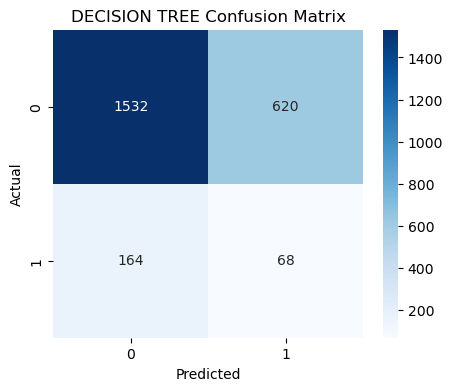

DECISION TREE ROC AUC Score: 0.501


--- RANDOM FOREST Evaluation ---
              precision    recall  f1-score   support

           0       0.89      0.65      0.75      2152
           1       0.08      0.27      0.12       232

    accuracy                           0.62      2384
   macro avg       0.49      0.46      0.44      2384
weighted avg       0.81      0.62      0.69      2384



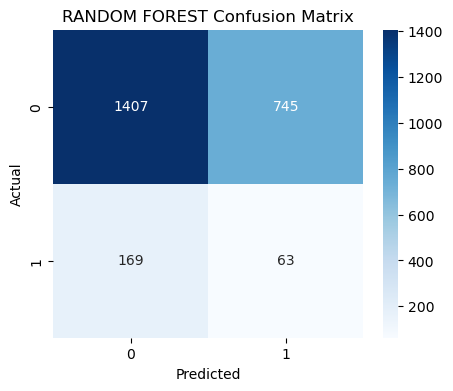

RANDOM FOREST ROC AUC Score: 0.457



In [53]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    print(f"\n--- {model_name} Evaluation ---")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        print(f"{model_name} ROC AUC Score: {auc:.3f}\n")
    else:
        print()

evaluate_model(dt_best_model, X_test, y_test, "DECISION TREE")
evaluate_model(rf_best_model, X_test, y_test, "RANDOM FOREST")

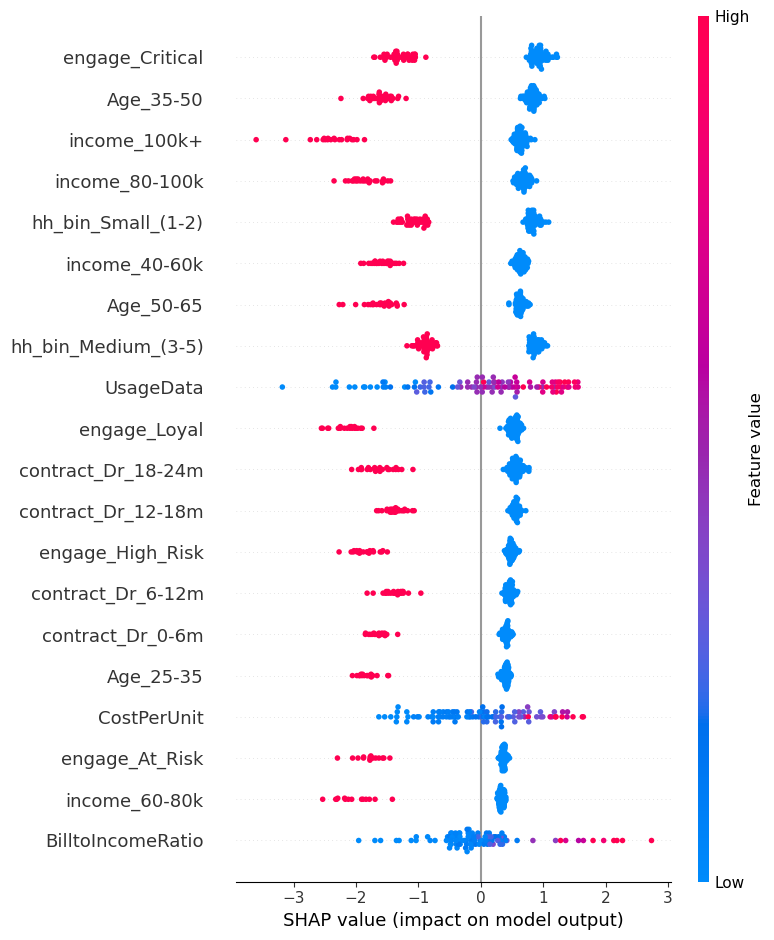

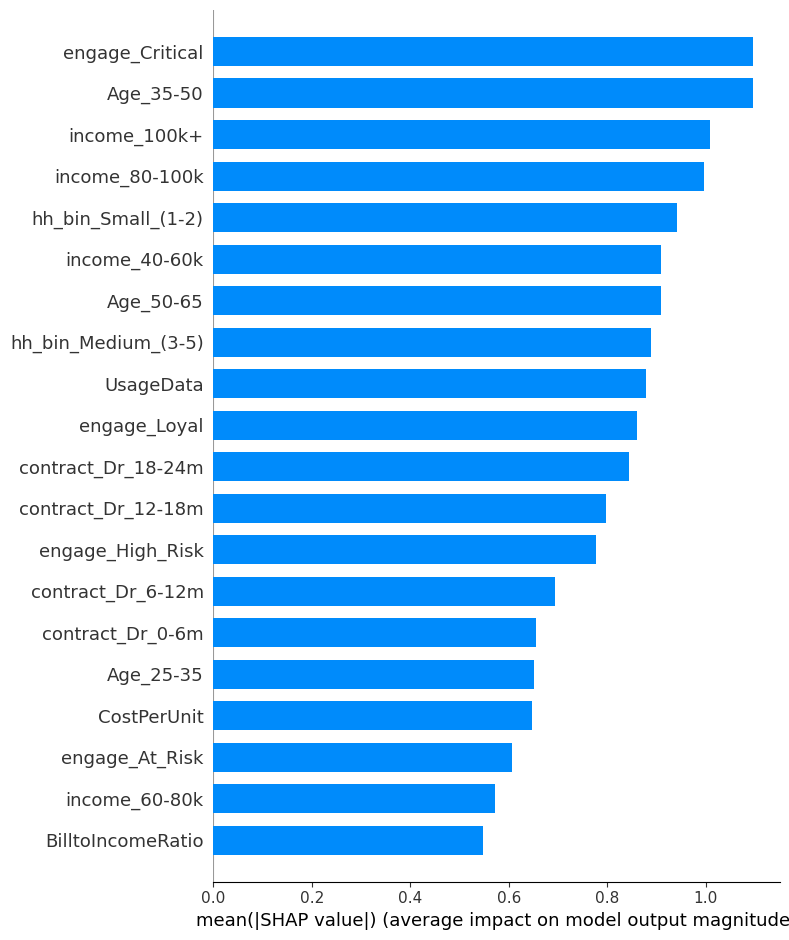

In [ ]:
import shap
import matplotlib.pyplot as plt

shap.initjs()

def explain_model(model, X_sample, model_name):
    explainer = shap.Explainer(model, X_sample)
    shap_values = explainer(X_sample)
    
    plt.title(f"{model_name} Feature Importance")
    shap.summary_plot(shap_values, X_sample)
    
    plt.title(f"{model_name} Feature Effects")
    shap.summary_plot(shap_values, X_sample, plot_type="bar")

X_sample = X_test.sample(n=100, random_state=42)

explain_model(xgb_model, X_sample, "Decision Tree")